### Le Thanh Phuong Nam - 25MS23308 - MSA34HCM
## HOMEWORK 3

In [1]:
!pip install -q torch torchvision torchaudio
!pip install -q ultralytics opencv-python matplotlib tqdm requests
!pip install -q deepface tensorflow
!pip install -q insightface onnxruntime onnx
!pip install -q tf-keras


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip


### Download yolo & yolo-face

In [2]:
import os
import requests
from pathlib import Path

repo_dir = Path("yolo-face")
if not repo_dir.is_dir():
    os.system("git clone https://github.com/YapaLab/yolo-face.git")

weights_dir = repo_dir / "weights"
weights_dir.mkdir(parents=True, exist_ok=True)

def download_if_missing(url: str, out_path: Path, desc: str):
    if out_path.exists():
        return
    resp = requests.get(url, timeout=120)
    resp.raise_for_status()
    out_path.write_bytes(resp.content)
    print(f"Đã tải {desc}")

# yolo11 (detector người/mèo/chó)
det_variant = "s"
yolo_det_name = f"yolo11{det_variant}.pt"
yolo_det_url  = f"https://github.com/ultralytics/assets/releases/download/v8.3.0/{yolo_det_name}"
download_if_missing(yolo_det_url, Path(yolo_det_name), yolo_det_name)

# yolov11-face (phát hiện khuôn mặt)
face_variant = "n"
yolo_face_name = f"yolov11{face_variant}-face.pt"
yolo_face_path = weights_dir / yolo_face_name
yolo_face_url  = f"https://github.com/YapaLab/yolo-face/releases/download/v0.0.0/{yolo_face_name}"
download_if_missing(yolo_face_url, yolo_face_path, yolo_face_name)

# kiểm tra ảnh vào
if not Path("kids.jpg").exists():
    raise FileNotFoundError("Đặt ảnh 'kids.jpg' cạnh notebook.")
else:
    print("kids.jpg sẵn sàng")

kids.jpg sẵn sàng


### Khởi tạo model (yolo người/face, insightface)

In [3]:
import warnings
warnings.filterwarnings("ignore")

import cv2
import torch
from ultralytics import YOLO
from insightface.app import FaceAnalysis

device = "0" if torch.cuda.is_available() else "cpu"
use_half = torch.cuda.is_available()
torch.set_num_threads(4)

print("Tải YOLO11...")
yolo_person_animal = YOLO("yolo11s.pt")
yolo_face = YOLO("yolo-face/weights/yolov11n-face.pt")
print("Đã tải YOLO11")

print("Tải InsightFace (age/gender)...")
insight_app = FaceAnalysis(
    name="buffalo_l",
    allowed_modules=["detection", "genderage"]
)
insight_ctx = 0 if torch.cuda.is_available() else -1
insight_app.prepare(ctx_id=insight_ctx, det_size=(640, 640))
print("Đã tải InsightFace")

coco_class_map = {0: "person", 15: "cat", 16: "dog"}

Tải YOLO11...
Đã tải YOLO11
Tải InsightFace (age/gender)...
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
model ignore: /Users/sofnb25/.insightface/models/buffalo_l/1k3d68.onnx landmark_3d_68
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
model ignore: /Users/sofnb25/.insightface/models/buffalo_l/2d106det.onnx landmark_2d_106
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /Users/sofnb25/.insightface/models/buffalo_l/det_10g.onnx detection [1, 3, '?', '?'] 127.5 128.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /Users/sofnb25/.insightface/models/buffalo_l/genderage.onnx genderage ['None', 3, 96, 96] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
model ignore: /Users/sofnb25/.insightface/models/buffalo_l/w600k_r50.onnx recognition
set det-size: (640, 

### Helper

In [4]:
import numpy as np

def iou(box_a, box_b):
    ax1, ay1, ax2, ay2 = box_a[:4]
    bx1, by1, bx2, by2 = box_b[:4]
    ix1, iy1 = max(ax1, bx1), max(ay1, by1)
    ix2, iy2 = min(ax2, bx2), min(ay2, by2)
    iw, ih = max(0, ix2 - ix1), max(0, iy2 - iy1)
    inter = iw * ih
    area_a = (ax2 - ax1) * (ay2 - ay1)
    area_b = (bx2 - bx1) * (by2 - by1)
    return inter / (area_a + area_b - inter + 1e-6)

def nms_boxes(boxes, iou_thr=0.5):
    if not boxes:
        return []
    arr = np.array(boxes, dtype=float)
    x1, y1, x2, y2, score = arr[:,0], arr[:,1], arr[:,2], arr[:,3], arr[:,4]
    order = np.argsort(score)[::-1]
    keep = []
    while order.size > 0:
        i = order[0]
        keep.append(i)
        if order.size == 1:
            break
        xx1 = np.maximum(x1[i], x1[order[1:]])
        yy1 = np.maximum(y1[i], y1[order[1:]])
        xx2 = np.minimum(x2[i], x2[order[1:]])
        yy2 = np.minimum(y2[i], y2[order[1:]])
        w = np.maximum(0, xx2 - xx1)
        h = np.maximum(0, yy2 - yy1)
        inter = w * h
        area_i = (x2[i] - x1[i]) * (y2[i] - y1[i])
        area_j = (x2[order[1:]] - x1[order[1:]]) * (y2[order[1:]] - y1[order[1:]])
        iou_vals = inter / (area_i + area_j - inter + 1e-6)
        order = order[1:][iou_vals <= iou_thr]
    return [tuple(map(int, arr[i, :4])) + (float(arr[i, 4]),) for i in keep]

def box_center(box):
    x1, y1, x2, y2 = box[:4]
    return (0.5 * (x1 + x2), 0.5 * (y1 + y2))

def point_in_box(pt, box):
    x, y = pt
    x1, y1, x2, y2 = box[:4]
    return (x1 <= x <= x2) and (y1 <= y <= y2)

def dedupe_faces(face_boxes, iou_thr=0.6, center_dist_thr=18):
    if not face_boxes:
        return []
    sorted_boxes = sorted(face_boxes, key=lambda b: b[4], reverse=True)
    kept = []
    for b in sorted_boxes:
        drop = False
        cx, cy = box_center(b)
        for k in kept:
            if iou(b, k) > iou_thr:
                drop = True
                break
            kx, ky = box_center(k)
            if ((cx - kx) ** 2 + (cy - ky) ** 2) ** 0.5 < center_dist_thr:
                drop = True
                break
        if not drop:
            kept.append(b)
    return kept

def age_group_label(age_val: int):
    if age_val <= 2:   return "Infant (0-2)"
    if age_val <= 6:   return "Toddler (3-6)"
    if age_val <= 12:  return "Child (7-12)"
    if age_val <= 17:  return "Teen (13-17)"
    if age_val <= 29:  return "Young Adult (18-29)"
    if age_val <= 49:  return "Adult (30-49)"
    if age_val <= 64:  return "Middle-Aged (50-64)"
    return "Senior (65+)"

### Pipeline: detect -> filter -> analyze -> render

Woman, Adult (30-49), happy
Girl, Child (7-12), happy
Man, Adult (30-49), fear
Girl, Toddler (3-6), neutral


so_nguoi: 4
so_dong_vat: 1
so_khuon_mat: 4
đã lưu: result_final.jpg


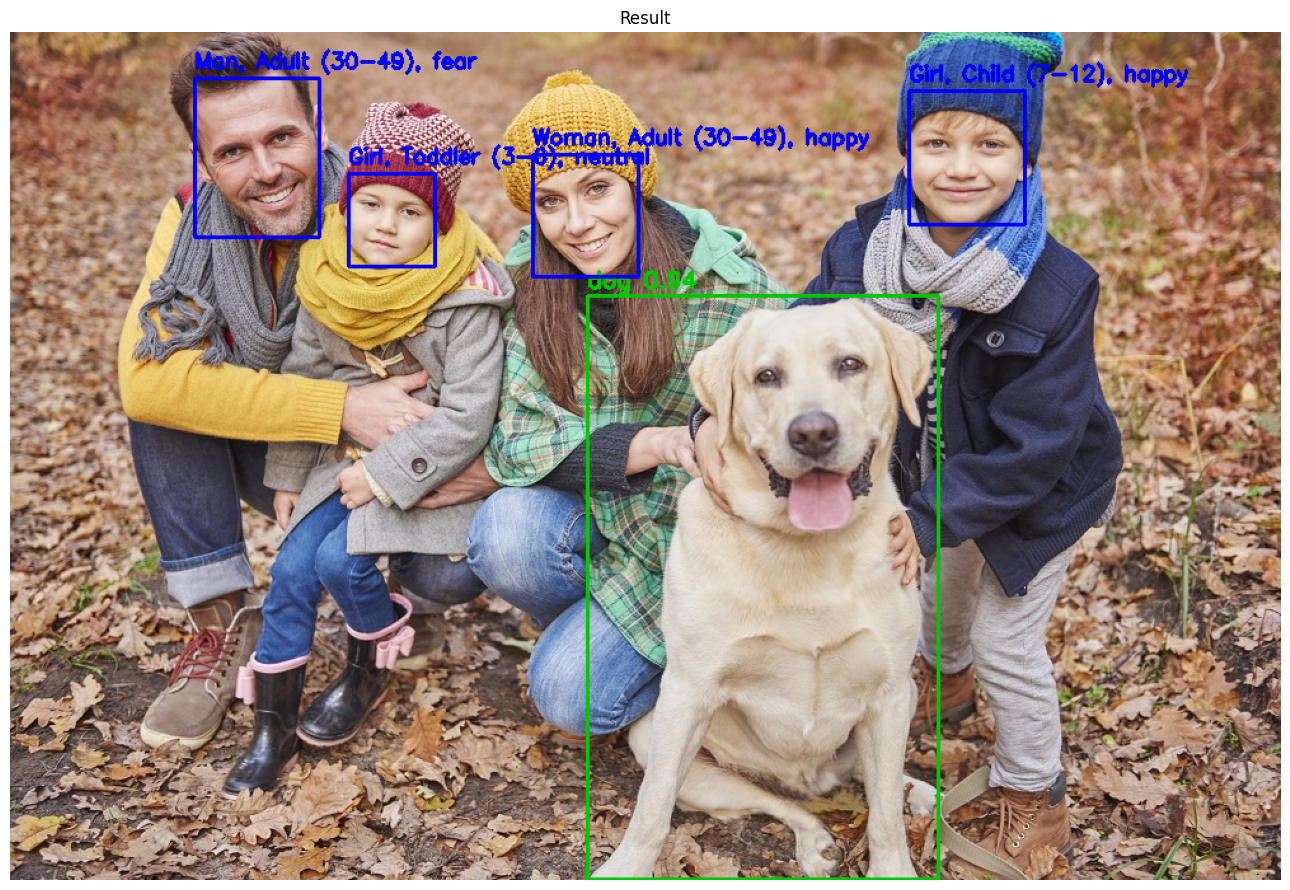

In [5]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from deepface import DeepFace

try:
    cv2.setLogLevel(0)
except Exception:
    pass

input_image = "kids.jpg"
output_image = "result_final.jpg"
detect_conf = 0.35

image_bgr = cv2.imread(input_image)
if image_bgr is None:
    raise FileNotFoundError("Không tìm thấy 'kids.jpg'.")

h, w = image_bgr.shape[:2]
render_bgr = image_bgr.copy()

# 1) object detection (person/cat/dog)
det_res = yolo_person_animal.predict(
    source=image_bgr[:, :, ::-1],
    imgsz=768,
    conf=detect_conf,
    classes=list(coco_class_map.keys()),
    device=device,
    verbose=False,
    half=use_half
)[0]

person_boxes, animal_list = [], []
if det_res.boxes is not None:
    for b in det_res.boxes:
        cls_id = int(b.cls.item())
        score = float(b.conf.item())
        x1, y1, x2, y2 = map(int, b.xyxy[0].tolist())
        if cls_id == 0:
            person_boxes.append((x1, y1, x2, y2, score))
        elif cls_id in (15, 16):
            animal_list.append((x1, y1, x2, y2, coco_class_map[cls_id], score))

person_boxes = nms_boxes(person_boxes, iou_thr=0.5)
animal_boxes_only = [(x1, y1, x2, y2) for (x1, y1, x2, y2, _, _) in animal_list]

# vẽ động vật (dog/cat)
for (x1, y1, x2, y2, label, score) in animal_list:
    color = (0, 200, 0) if label == "dog" else (200, 0, 200)
    cv2.rectangle(render_bgr, (x1, y1), (x2, y2), color, 2)
    cv2.putText(render_bgr, f"{label} {score:.2f}", (x1, max(0, y1 - 6)),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)

# 2) face detection (insightface) — lọc mặt thuộc động vật
image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
insight_faces = insight_app.get(image_rgb)

human_faces = []
for f in insight_faces:
    x1, y1, x2, y2 = map(int, f.bbox)
    cx, cy = box_center((x1, y1, x2, y2, 1.0))
    if not any(point_in_box((cx, cy), ab) for ab in animal_boxes_only):
        human_faces.append(f)

# 3) phân tích khuôn mặt (age/gender từ insightface; age/emotion từ deepface)
faces_info = []
pad_ratio = 0.25

for f in human_faces:
    x1, y1, x2, y2 = map(int, f.bbox)
    face_h = y2 - y1
    age_if = int(f.age) if f.age is not None else 0
    gender_if = int(f.gender) if f.gender is not None else -1  

    pad_h, pad_w = int(face_h * pad_ratio), int((x2 - x1) * pad_ratio)
    cx1 = max(0, x1 - pad_w)
    cy1 = max(0, y1 - pad_h)
    cx2 = min(w, x2 + pad_w)
    cy2 = min(h, y2 + pad_h)
    crop_bgr = image_bgr[cy1:cy2, cx1:cx2]

    age_df = None
    emotion = "neutral"
    if crop_bgr.size > 0:
        try:
            df_out = DeepFace.analyze(
                crop_bgr,
                actions=["age", "emotion"],
                detector_backend="skip",
                enforce_detection=False,
                silent=True
            )
            if isinstance(df_out, (list, tuple)):
                df_out = df_out[0]
            age_df = int(df_out.get("age", 0))
            emotion = df_out.get("dominant_emotion", "neutral")
        except Exception:
            pass

    faces_info.append({
        "bbox": (x1, y1, x2, y2),
        "face_h": face_h,
        "age_if": age_if,
        "age_df": age_df,
        "gender_if": gender_if,
        "emotion": emotion
    })

# median để chuẩn hóa tương đối
ages_df = [fi["age_df"] for fi in faces_info if fi["age_df"]]
face_heights = [fi["face_h"] for fi in faces_info]

median_age_df = (sorted(ages_df)[len(ages_df)//2] if ages_df else 30)
median_age_if = (sorted([fi["age_if"] for fi in faces_info])[len(faces_info)//2] if faces_info else 30)
median_face_h = (sorted(face_heights)[len(face_heights)//2] if face_heights else max(1, h // 12))

# 4) hậu xử lý + vẽ

for fi in faces_info:
    x1, y1, x2, y2 = fi["bbox"]
    face_h = fi["face_h"]
    age_if = fi["age_if"]
    age_df = fi["age_df"]
    gender_if = fi["gender_if"]
    emotion = fi["emotion"]

    child_score = 0.0

    if age_df and median_age_df > 0:
        df_dev = (median_age_df - age_df) / median_age_df
        if df_dev > 0.30:
            child_score += min(1.5, df_dev * 3)
    else:
        df_dev = 0.0

    if median_age_if > 0:
        if_dev = (median_age_if - age_if) / median_age_if
        if if_dev > 0.20:
            child_score += min(1.0, if_dev * 2)
    else:
        if_dev = 0.0

    if median_face_h > 0:
        size_dev = (median_face_h - face_h) / median_face_h
        if size_dev > 0.15:
            child_score += min(1.2, size_dev * 4)

    if age_df and age_if and (df_dev > 0.2) and (if_dev > 0.1):
        child_score += 0.5

    is_child = (child_score >= 1.2)

    if is_child:
        candidates = []
        if age_df and age_df > 0:
            candidates.append(age_df)
        if age_if and age_if > 0 and age_if < median_age_if:
            candidates.append(age_if)
        min_age = min(candidates) if candidates else 10

        if child_score >= 3.0:
            final_age = max(3, min(8, min_age // 3))
        elif child_score >= 2.0:
            final_age = max(5, min(12, min_age // 2))
        else:
            final_age = max(6, min(12, int(min_age * 0.55)))
    else:
        if age_df and 18 <= age_df < 80:
            final_age = age_df
        elif age_if and 18 <= age_if < 80:
            final_age = age_if
        else:
            final_age = 35

    if final_age <= 17:
        gender_text = "Boy" if gender_if == 1 else "Girl"
    else:
        gender_text = "Man" if gender_if == 1 else "Woman"

    age_text = age_group_label(final_age)
    display_text = f"{gender_text}, {age_text}, {emotion}"

    cv2.rectangle(render_bgr, (x1, y1), (x2, y2), (255, 0, 0), 2)
    cv2.putText(render_bgr, display_text, (x1, max(0, y1 - 8)),
                cv2.FONT_HERSHEY_SIMPLEX, 0.55, (255, 0, 0), 2)

    print(display_text)

print("\n")
print(f"so_nguoi: {len(person_boxes)}")
print(f"so_dong_vat: {len(animal_list)}")
print(f"so_khuon_mat: {len(faces_info)}")

cv2.imwrite(output_image, render_bgr)
print(f"đã lưu: {output_image}")

plt.figure(figsize=(14, 9))
plt.imshow(cv2.cvtColor(render_bgr, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title("Result")
plt.tight_layout()
plt.show()

In [7]:
import cv2
from ultralytics import YOLO

# 1. Load model YOLO nhận diện khuôn mặt mà bạn đã tải
# Lưu ý: Đảm bảo đường dẫn file .pt đúng với nơi bạn lưu
try:
    model = YOLO("yolo-face/weights/yolov11n-face.pt")
except Exception:
    print("Không tìm thấy model face chuyên dụng, chuyển sang dùng model mặc định (kém chuẩn hơn chút)")
    model = YOLO("yolov8n.pt") # Fallback nếu không thấy file kia

# 2. Mở Webcam (0 là camera mặc định)
cap = cv2.VideoCapture(0)

# Cấu hình ngưỡng tin cậy (chỉ hiện khung nếu chắc chắn > 50%)
CONF_THRESHOLD = 0.5

print("Đang chạy camera... Nhấn 'q' để thoát.")

while True:
    ret, frame = cap.read()
    if not ret:
        break

    # 3. Đưa hình ảnh vào mô hình để detect
    # stream=True giúp tối ưu bộ nhớ khi chạy video liên tục
    results = model.predict(frame, conf=CONF_THRESHOLD, verbose=False, stream=True)

    # 4. Lấy kết quả và vẽ lên màn hình
    for result in results:
        boxes = result.boxes
        for box in boxes:
            # Lấy toạ độ khung hình chữ nhật: x1, y1, x2, y2
            x1, y1, x2, y2 = map(int, box.xyxy[0])
            
            # Lấy độ tin cậy (Confidence score)
            score = float(box.conf[0])

            # Vẽ khung chữ nhật quanh mặt
            cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 255, 0), 2)
            
            # Viết chữ "Face" và độ tin cậy
            label = f"Face: {score:.2f}"
            cv2.putText(frame, label, (x1, y1 - 10), 
                        cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)

    # 5. Hiển thị
    cv2.imshow("Simple Face Detection", frame)

    # Nhấn 'q' để thoát
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()

Đang chạy camera... Nhấn 'q' để thoát.
